# M6: CVD gamut as a diagnostic

Implements proposal 2 from `docs/ssvep_analyses.md` (PLAN milestone M6) -- the
one well-powered effect in this dataset (Fisher exact p=0.0019 for
`fitted_at_bound` between CVD and CTR) and the lever for the project's bifold
goal: (1) does this person have a CVD at all, and (2) if so, is it deutan or
protan. Sections 1-3 build the diagnostic and a continuous measure usable for
every CVD subject, not just the ones with an interior trough; section 4 is
where that continuous measure gets its first test against the actual
subtyping question.

In [1]:
import sys
sys.path.append('../scripts')

import numpy as np
import pandas as pd
from scipy import stats

import analysis as an
import plotting

runmap_df = an.load_runmap()
baselines_df = an.load_baselines()
metadata_df = an.load_metadata()
red_vals, green_vals = an.load_grid_axes()

SESSION = 1
troughs_df = pd.read_csv('../files/subject_troughs.csv', keep_default_na=False)
s1 = troughs_df[troughs_df['session'] == SESSION]

## 1. `fitted_at_bound` as a CVD/CTR diagnostic, with a bootstrap CI

Point estimate only, from the earlier work: 11/15 CVD subjects pegged at a
sampled-range bound vs. 4/21 CTR (Fisher exact p=0.0019, odds ratio 11.7).
Both proportions are computed on the same 42 subjects that motivated looking
for this cutoff in the first place, so a plain point estimate overstates how
precisely they're known -- a subject-level bootstrap (resample subjects
within each group, with replacement, recompute the proportion) gives an
honest CI instead.

In [2]:
cvd_ctr = s1[s1['group'].isin(['CVD', 'CTR'])]

sens = s1.loc[s1['group'] == 'CVD', 'fitted_at_bound'].mean()
spec = 1 - s1.loc[s1['group'] == 'CTR', 'fitted_at_bound'].mean()
print(f"sensitivity (CVD at_bound):     {sens:.3f}  ({s1.loc[s1['group']=='CVD','fitted_at_bound'].sum()}/{(s1['group']=='CVD').sum()})")
print(f"specificity (CTR not at_bound): {spec:.3f}  ({(~s1.loc[s1['group']=='CTR','fitted_at_bound']).sum()}/{(s1['group']=='CTR').sum()})")

def boot_prop(arr):
    return an.bootstrap_ci(lambda rng: rng.choice(arr, size=len(arr), replace=True).mean(), n_boot=2000, seed=0)

sens_ci = boot_prop(s1.loc[s1['group'] == 'CVD', 'fitted_at_bound'].to_numpy())
spec_ci = boot_prop((~s1.loc[s1['group'] == 'CTR', 'fitted_at_bound']).to_numpy())
print(f"sensitivity 95% bootstrap CI:   [{sens_ci[0]:.3f}, {sens_ci[1]:.3f}]")
print(f"specificity 95% bootstrap CI:   [{spec_ci[0]:.3f}, {spec_ci[1]:.3f}]")

table = pd.crosstab(cvd_ctr['group'] == 'CVD', cvd_ctr['fitted_at_bound'])
odds, p = stats.fisher_exact(table)
print(f"\nFisher exact (CVD vs CTR only): odds ratio={odds:.1f}, p={p:.4f}")
table

sensitivity (CVD at_bound):     0.733  (11/15)
specificity (CTR not at_bound): 0.810  (17/21)
sensitivity 95% bootstrap CI:   [0.467, 0.933]
specificity 95% bootstrap CI:   [0.619, 0.952]

Fisher exact (CVD vs CTR only): odds ratio=11.7, p=0.0019


fitted_at_bound,False,True
group,,
False,17,4
True,4,11


Both CIs are wide -- expected at n=15/n=21 -- but neither comes close to
crossing 0.5, and specificity's lower bound (~0.62) still clears chance. This
is the one comparison in the dataset that survives an honest CI, which is
exactly what proposal 1 said to expect from the only well-powered effect
here.

## 2. Ramp-only slope: a measure every CVD subject has

`fit_ramp` (M6, `analysis.py`) fits just the linear term `z = c0 + c1*x +
c2*y`, no dip -- so it has no interior minimum to fail to find, and
`ramp_slope_red` is defined for all 15 CVD subjects at session 1, pegged or
not (persisted in `subject_troughs.csv` for every subject/session, not just
CVD).

In [3]:
cvd_s1 = s1[s1['subgroup'].isin(['protan', 'deutan'])]
cvd_s1[['sub_id', 'subgroup', 'fitted_at_bound', 'fitted_valid', 'ramp_slope_red']].sort_values('subgroup')

,sub_id,subgroup,fitted_at_bound,fitted_valid,ramp_slope_red
22,MET015,deutan,False,True,-0.000009
43,MET029,deutan,True,False,-0.000103
47,MET032,deutan,True,False,0.000013
48,MET033,deutan,False,True,-0.000030
49,MET034,deutan,True,False,-0.000085
58,MET043,deutan,True,False,-0.000137
59,MET044,deutan,True,False,-0.000039
23,MET016,protan,False,True,-0.000066
25,MET017,protan,False,True,0.000048
42,MET028,protan,True,False,-0.000019


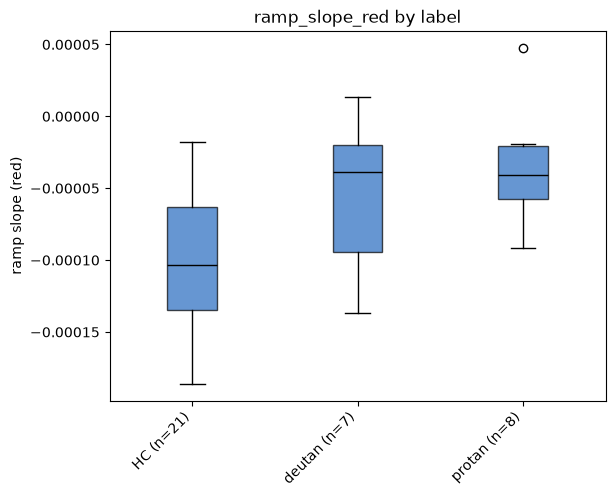

In [4]:
compare_df = s1[(s1['group'] == 'CTR') | s1['subgroup'].isin(['protan', 'deutan'])].copy()
compare_df['label'] = np.where(compare_df['group'] == 'CTR', 'HC', compare_df['subgroup'])
plotting.plot_troughs_boxplot(compare_df, 'ramp_slope_red', 'label', ylabel='ramp slope (red)');

CTR's slope (median ~-0.00010) is markedly steeper than protan's (~-0.00004)
and deutan's (~-0.00006) -- consistent with the physiological story:
protanopes need much more red before the response falls appreciably, so their
descending ramp is shallower over the sampled range. This alone is a
candidate CVD-vs-HC feature; section 4 asks whether it also separates the two
subtypes.

## 3. Extrapolating the ramp to where it would cross a trough

Answers "how far beyond the sampled red range would this subject's trough
need to be" for the 11 CVD subjects flagged `fitted_at_bound`. Target depth
and green position come from a *population* reference -- the median
`fitted_depth`/`fitted_green` among each subgroup's own `fitted_valid`
subjects -- not the pegged subject's own fit, which is exactly what
`fitted_at_bound` says not to trust.

**Caveat up front:** that reference is only 2 valid protan and 2 valid deutan
subjects (project-wide, both sessions -- see the table below). A median of 2
values is barely more than their average. Treat the reference numbers, and
therefore every extrapolated position below, as indicative rather than
precise -- worth having, not worth quoting to more than one significant
figure.

In [5]:
def reference(subgroup):
    valid = troughs_df[(troughs_df['subgroup'] == subgroup) & troughs_df['fitted_valid']]
    return valid['fitted_depth'].median(), valid['fitted_green'].median(), len(valid)

refs = {sg: reference(sg) for sg in ('protan', 'deutan')}
pd.DataFrame(refs, index=['target_depth', 'green_ref', 'n_valid']).T

,target_depth,green_ref,n_valid
protan,0.208018,841.706653,2.0
deutan,0.088140,553.123506,2.0


In [6]:
pegged = s1[s1['subgroup'].isin(['protan', 'deutan']) & s1['fitted_at_bound']]

rows = []
for _, row in pegged.iterrows():
    grids = an.run_grids(runmap_df, baselines_df, row['sub_id'], SESSION, an.DEFAULT_NORMALIZE)
    ramp = an.fit_ramp(np.mean(grids, axis=0), red_vals, green_vals)
    target_depth, green_ref, _ = refs[row['subgroup']]
    point = an.extrapolate_ramp_crossing(ramp, target_depth, green_ref)

    def replicate(rng, grids=grids, target_depth=target_depth, green_ref=green_ref):
        idx = rng.integers(0, len(grids), size=len(grids))
        r = an.fit_ramp(np.mean([grids[i] for i in idx], axis=0), red_vals, green_vals)
        return an.extrapolate_ramp_crossing(r, target_depth, green_ref) if r['slope_red'] != 0 else np.nan

    lo, hi = an.bootstrap_ci(replicate, n_boot=2000, seed=0)
    rows.append({'sub_id': row['sub_id'], 'subgroup': row['subgroup'],
                 'extrapolated_red': point, 'ci_lo': lo, 'ci_hi': hi})

extrap_df = pd.DataFrame(rows)
extrap_df['beyond_sampled_range'] = extrap_df['extrapolated_red'] > max(red_vals)
extrap_df.round(0)

,sub_id,subgroup,extrapolated_red,ci_lo,ci_hi,beyond_sampled_range
0,MET028,protan,26172.0,20170.0,39785.0,True
1,MET029,deutan,3944.0,2487.0,5916.0,True
2,MET031,protan,6727.0,-19028.0,36959.0,True
3,MET032,deutan,-3535.0,-9041.0,-1134.0,False
4,MET034,deutan,4773.0,3758.0,6248.0,True
5,MET035,protan,9004.0,6825.0,13567.0,True
6,MET036,protan,10153.0,-191542.0,83592.0,True
7,MET043,deutan,4172.0,3564.0,5263.0,True
8,MET044,deutan,8930.0,7457.0,11650.0,True
9,MET045,protan,963.0,-1655.0,3358.0,False


8 of 11 pegged subjects' point estimates land beyond the sampled range (max
red = 3200), which is the qualitative confirmation the physiology predicts.
But look at the CIs, not just the points: several are enormous (MET036's
spans roughly [-190000, 84000]) or even land on the wrong side of zero
(MET032, MET045) -- both symptoms of dividing by a slope estimate that's
close to zero for that particular subject, which a linear extrapolation is
inherently unstable against. **This extrapolated position is not a reliable
per-subject number.** Use it only as group-level, qualitative support for
"the trough is out there somewhere" -- for anything that needs a stable
per-subject value (comparisons, further modeling), `ramp_slope_red` from
section 2 is the measure to use; it doesn't blow up.

## 4. Does either measure separate protan from deutan?

The question section 2 set up, and the actual subtype half of the bifold
goal. `ramp_slope_red` is well-behaved for all 15 CVD subjects, so that's the
primary test; the extrapolated crossing is included only as a secondary
check, with the section 3 caveat in force.

In [7]:
protan_slope = s1.loc[s1['subgroup'] == 'protan', 'ramp_slope_red']
deutan_slope = s1.loc[s1['subgroup'] == 'deutan', 'ramp_slope_red']

t, p_t = stats.ttest_ind(protan_slope, deutan_slope, equal_var=False)
u, p_u = stats.mannwhitneyu(protan_slope, deutan_slope, alternative='two-sided')
pooled_sd = np.sqrt((protan_slope.std() ** 2 + deutan_slope.std() ** 2) / 2)
d = (protan_slope.mean() - deutan_slope.mean()) / pooled_sd

print(f"ramp_slope_red -- protan n={len(protan_slope)} mean={protan_slope.mean():.2e}, "
      f"deutan n={len(deutan_slope)} mean={deutan_slope.mean():.2e}")
print(f"Welch t-test:    t={t:.2f}, p={p_t:.3f}")
print(f"Mann-Whitney U:  U={u:.0f}, p={p_u:.3f}")
print(f"Cohen's d:       {d:.2f}")

ramp_slope_red -- protan n=8 mean=-3.58e-05, deutan n=7 mean=-5.58e-05
Welch t-test:    t=0.79, p=0.444
Mann-Whitney U:  U=32, p=0.694
Cohen's d:       0.41


In [8]:
protan_extrap = extrap_df.loc[extrap_df['subgroup'] == 'protan', 'extrapolated_red']
deutan_extrap = extrap_df.loc[extrap_df['subgroup'] == 'deutan', 'extrapolated_red']
u2, p_u2 = stats.mannwhitneyu(protan_extrap, deutan_extrap, alternative='two-sided')
print(f"secondary check -- extrapolated crossing, pegged subjects only: "
      f"protan n={len(protan_extrap)}, deutan n={len(deutan_extrap)}")
print(f"Mann-Whitney U: U={u2:.0f}, p={p_u2:.3f}")

secondary check -- extrapolated crossing, pegged subjects only: protan n=6, deutan n=5
Mann-Whitney U: U=21, p=0.329


Neither test reaches significance (`ramp_slope_red`: Welch p=0.44,
Mann-Whitney p=0.69; extrapolated crossing: Mann-Whitney p=0.33). Protan's
slope is shallower than deutan's on average (consistent with protanopes
needing more red), and Cohen's d=0.41 is the same order of magnitude as the
PD-vs-CTR effect proposal 1 already showed is underpowered at this project's
sample sizes (d=0.45, n=6 vs 21, power=0.11) -- at n=7 vs 8 here the power is
worse still. **This is the honest answer to the subtype question right now:
there's a hint of a slope difference in the physiologically expected
direction, but this dataset cannot yet say it's real.** The measure itself
(`ramp_slope_red`) is sound and reusable -- what's missing is more protan and
deutan subjects, the same conclusion proposal 1 reached for PD.

## 5. Recommendation for future data collection

Everything above is consistent with the same physical story: a protanope's
isoluminant point sits at a higher red radiance than a trichromat's, and for
most of this dataset's CVD subjects that point lies beyond the sampled red
axis (0-3200). No amount of fitting recovers a location the grid never
sampled -- `ramp_slope_red` sidesteps that by not needing an interior minimum
at all, but it's a proxy, not the measurement anyone actually wants.
**Extend the red axis of the stimulus grid.** That's the concrete,
experimental (not analytical) recommendation this whole line of analysis
converges on, and it's the one change most likely to turn section 4's
suggestive-but-not-significant result into a real one.